In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

paths = [
    Path('../Data/processed/scored_loans.csv'),
    Path('../data/processed/scored_loans.csv'),
    Path('data/processed/scored_loans.csv'),
    Path('../Data/scored_loans.csv'),
    Path('../data/scored_loans.csv'),
]

for p in paths:
    if p.exists():
        test_results = pd.read_csv(p)
        break
else:
    raise FileNotFoundError(f'Could not find scored_loans.csv in expected locations: {paths}')

In [10]:
test_results.head(10)

,actual,probability_of_default,risk_band,decision,credit_score
0,0,0.050959,Very Low Risk,Approve,822
1,0,0.064676,Very Low Risk,Approve,814
2,0,0.120008,Low Risk,Manual Review,784
3,1,0.262928,High Risk,Reject,705
4,0,0.035043,Very Low Risk,Approve,831
5,0,0.131965,Low Risk,Manual Review,777
6,0,0.236114,High Risk,Manual Review,720
7,0,0.210915,Medium Risk,Manual Review,734
8,0,0.056794,Very Low Risk,Approve,819
9,0,0.047949,Very Low Risk,Approve,824


In [11]:
test_results.columns

Index(['actual', 'probability_of_default', 'risk_band', 'decision',
       'credit_score'],
      dtype='str')

In [12]:
# Create Odds
test_results["odds"] = (
    (1 - test_results["probability_of_default"])
    /
    test_results["probability_of_default"]
)

In [14]:
# Create Log Odds
test_results["log_odds"] = np.log(
    test_results["odds"]
)

test_results[
    [
        "probability_of_default",
        "odds",
        "log_odds"
    ]
].head()

,probability_of_default,odds,log_odds
0,0.050959,18.623810,2.924441
1,0.064676,14.461574,2.671495
2,0.120008,7.332805,1.992358
3,0.262928,2.803323,1.030805
4,0.035043,27.536616,3.315517


<Axes: >

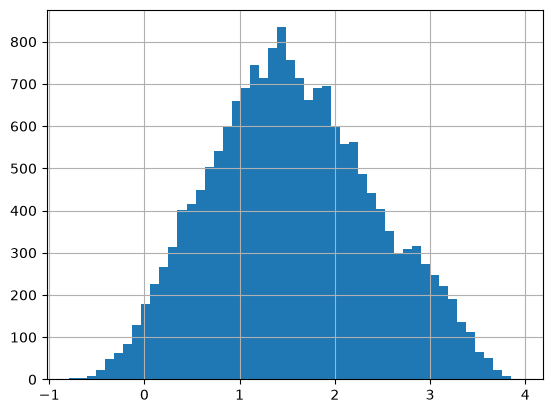

In [15]:
#Visualize Distributions
test_results["log_odds"].hist(
    bins=50
)